In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
from pathlib import Path
import sys
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import lightning as L
import wandb
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import random_split, DataLoader
from monai.networks.nets import UNet

sys.path.append('../')
from dataset import PMRIDataset, MNMv2Dataset, ACDCDataset
from data_utils import (
    PMRIDataModule,
    MNMv2DataModule
)
from model.unet import get_unet


nnUNet_raw_data_base is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
RESULTS_FOLDER is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.


In [30]:
# ### Load basic config
# cfg = OmegaConf.load('../configs/basic_config_venusberg.yaml')
# OmegaConf.update(cfg, 'run.iteration', 0)

# ### Set dataset, either brain or heart
# DATA_KEY = 'heart'
# OmegaConf.update(cfg, 'run.data_key', DATA_KEY)


# ### get model
# # available models:
# #     - default-8
# #     - default-16
# #     - monai-8-4-4
# #     - monai-16-4-4
# #     - monai-16-4-8
# #     - monai-32-4-4
# #     - monai-64-4-4
# #     - swinunetr


# unet_name = 'default-8'
# postfix = ''
# args = unet_name.split('-')
# cfg.unet[DATA_KEY].pre = unet_name + postfix
# cfg.unet[DATA_KEY].arch = args[0]
# cfg.unet[DATA_KEY].n_filters_init = int(args[1])

# if args[0] == 'monai':
#     cfg.unet[DATA_KEY].depth = int(args[2])
#     cfg.unet[DATA_KEY].num_res_units = int(args[3])


# unet, state_dict = get_unet(
#     cfg,
#     update_cfg_with_swivels=False,
#     return_state_dict=True)
# unet.load_state_dict(state_dict)
# _ = unet.cuda()


### 
n_filters_init = 8
depth = 4
num_res_units = 4

unet = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=4,
    channels=[n_filters_init * 2 ** i for i in range(depth)],
    strides=[2] * (depth - 1),
    num_res_units=num_res_units
)

In [3]:
# pmri_dataset = PMRIDataset(
#     data_dir="../../../../../data/PMRI/",
#     vendor="ge",
# )
# pmri_loader = MultiImageSingleViewDataLoader(
#     data=pmri_dataset,
#     batch_size=4,
#     return_orig=False
# )
# pmri_transform_generator = Transforms(patch_size=[384, 384])
# pmri_transform = pmri_transform_generator.get_transforms("global_transforms")
# pmri_augmenter = MultiThreadedAugmenter(
#     data_loader=pmri_loader,
#     transform=pmri_transform,
#     num_processes=4,
#     num_cached_per_queue = 2, 
#     seeds=None
# )


In [60]:
# mnmv2_dataset = MNMv2Dataset(
#     datapath = "../../../../../data/MNM/",
#     vendor="siemens",
# )
# mnmv2_loader = MultiImageSingleViewDataLoader(
#     data=mnmv2_dataset,
#     batch_size=4,
#     return_orig=False
# )
# mnmv2_transform_generator = Transforms(patch_size=[256, 256])
# mnmv2_transform = mnmv2_transform_generator.get_transforms("global_transforms")
# mnmv2_augmenter = MultiThreadedAugmenter(
#     data_loader=mnmv2_loader,
#     transform=mnmv2_transform,
#     num_processes=4,
#     num_cached_per_queue = 2, 
#     seeds=None
# )

In [23]:

# class PMRIDataModule(L.LightningDataModule):
    
#     def __init__(
#         self,
#         data_dir: str,
#         vendor_assignment: dict[str, str],
#         batch_size: int = 32,
#     ):
#         super().__init__()
#         self.data_dir = data_dir
#         self.vendor_assignment = vendor_assignment
#         self.batch_size = batch_size
#         self.transforms = Transforms(patch_size=[384, 384])

#     def prepare_data(self):
#         # nothing to prepare for now. Data already downloaded
#         pass

#     def setup(self, stage=None):
#         if stage == 'fit':
#             pmri_full = PMRIDataset(
#                 data_dir=self.data_dir,
#                 vendor=self.vendor_assignment['train'],
#             )
#             self.pmri_train, self.pmri_val = pmri_full.random_split(
#                 val_size=0.1,
#             )

#         if stage == 'test':
#             self.pmri_test = PMRIDataset(
#                 data_dir=self.data_dir,
#                 vendor=self.vendor_assignment['test'],
#             )

#         if stage == 'predict':
#             self.prmi_predict = PMRIDataset(
#                 data_dir=self.data_dir,
#                 vendor=self.vendor_assignment['test'],
#             )


#     def train_dataloader(self):
#         pmri_train_loader = MultiImageSingleViewDataLoader(
#             data=self.pmri_train,
#             batch_size=self.batch_size,
#             return_orig=False
#         )
        
#         return MultiThreadedAugmenter(
#             data_loader=pmri_train_loader,
#             transform=self.transforms.get_transforms("global_transforms"),
#             num_processes=4,
#             num_cached_per_queue = 2, 
#             seeds=None
#         )
    
    
#     def val_dataloader(self):
#         return DataLoader(
#             self.pmri_val,
#             batch_size=self.batch_size,
#             shuffle=False,
#             drop_last=False,
#             pin_memory=True,
#             num_workers=4
#         )

    
#     def test_dataloader(self):
#         return DataLoader(
#             self.pmri_test,
#             batch_size=self.batch_size,
#             shuffle=False,
#             drop_last=False,
#             pin_memory=True,
#             num_workers=4
#         )
    

#     def predict_dataloader(self):
#         return DataLoader(
#             self.pmri_predict,
#             batch_size=self.batch_size,
#             shuffle=False,
#             drop_last=False,
#             pin_memory=True,
#             num_workers=4
#         )
    


# class MNMv2DataModule(L.LightningDataModule):
#     def __init__(
#         self,
#         data_dir: str,
#         vendor_assignment: dict,
#         batch_size: int = 32,
#         binary_mask: bool = False,
#         non_empty_target: bool = True,
#         seed: int = 42,
#     ):
#         super().__init__()
#         self.data_dir = data_dir
#         self.vendor_assignment = vendor_assignment  # Should be a dict with keys 'train', 'val', 'test'
#         self.batch_size = batch_size
#         self.binary_mask = binary_mask
#         self.non_empty_target = non_empty_target

#         self.transforms = Transforms(patch_size=[256, 256])  # Assuming similar transform object as PMRIDataModule


#     def prepare_data(self):
#         # Data is already prepared; nothing to do
#         pass


#     def setup(self, stage=None):
#         if stage == 'fit' or stage is None:
#             # Load full dataset for training
#             mnm_full = MNMv2Dataset(
#                 data_dir=self.data_dir,
#                 vendor=self.vendor_assignment.get('train'),
#                 binary_target=self.binary_mask,
#                 non_empty_target=self.non_empty_target,
#                 normalize=True,  # Always normalizing
#             )
#             # Split using MNMv2Dataset's custom method
#             self.mnm_train, self.mnm_val = mnm_full.random_split(val_size=0.1)

#         if stage == 'test' or stage is None:
#             self.mnm_test = MNMv2Dataset(
#                 data_dir=self.data_dir,
#                 vendor=self.vendor_assignment.get('test'),
#                 binary_target=self.binary_mask,
#                 non_empty_target=self.non_empty_target,
#                 normalize=True,
#             )

#         if stage == 'predict' or stage is None:
#             self.mnm_predict = MNMv2Dataset(
#                 data_dir=self.data_dir,
#                 vendor=self.vendor_assignment.get('predict', self.vendor_assignment.get('test')),
#                 binary_target=self.binary_mask,
#                 non_empty_target=self.non_empty_target,
#                 normalize=True,
#             )


#     def train_dataloader(self):
#         mnm_train_loader = MultiImageSingleViewDataLoader(
#             data=self.mnm_train,
#             batch_size=self.batch_size,
#             return_orig=False
#         )
        
#         return MultiThreadedAugmenter(
#             data_loader=mnm_train_loader,
#             transform=self.transforms.get_transforms("global_transforms"),
#             num_processes=4,
#             num_cached_per_queue=2,
#             seeds=None
#         )


#     def val_dataloader(self):
#         return DataLoader(
#             self.mnm_val,
#             batch_size=self.batch_size,
#             shuffle=False,
#             num_workers=4,
#             pin_memory=True,
#             drop_last=False  # Ensuring we do not drop the last batch
#         )


#     def test_dataloader(self):
#         return DataLoader(
#             self.mnm_test,
#             batch_size=self.batch_size,
#             shuffle=False,
#             num_workers=4,
#             pin_memory=True,
#             drop_last=False  # Ensuring we do not drop the last batch
#         )


#     def predict_dataloader(self):
#         return DataLoader(
#             self.mnm_predict,
#             batch_size=self.batch_size,
#             shuffle=False,
#             num_workers=4,
#             pin_memory=True,
#             drop_last=False  # Ensuring we do not drop the last batch
#         )


In [117]:
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU

dice_metric = DiceMetric(include_background=False, reduction="none")

# num_classes = output.shape[1]
# if num_classes > 1:
#     output = output.argmax(1)
# output = torch.nn.functional.one_hot(output, num_classes=num_classes).moveaxis(-1, 1)

# dsc = dice_metric(output, target)
# dsc.nanmean(0)

class LightningSegmentationModel(L.LightningModule):

    def __init__(
        self,
        model: torch.nn.Module,
        patience: int = 5,
        binary_target: bool = False,
        validation_metrics: dict = None,
    ):
        super().__init__()
        self.model = model
        self.patience = patience
        self.loss = DiceCELoss(
            softmax=False if binary_target else True,
            sigmoid=True if binary_target else False,
            to_onehot_y=False if binary_target else True,
        )
        self.dsc = DiceMetric(include_background=False, reduction="none")
        self.IoU = MeanIoU(include_background=False, reduction="none")

    def forward(self, inputs):        
        return self.model(inputs)
    
    def training_step(self, batch, batch_idx):
        input = batch['data']
        target = batch['target']
        outputs = self(input)
        loss = self.loss(outputs, target)

        self.log_dict({
            'train_loss': loss
        })
        return {
            'loss': loss
        }
    
    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        input = batch['input']
        target = batch['target']
        
        outputs = self(input)
        loss = self.loss(outputs, target)
        num_classes = outputs.shape[1]
        if num_classes > 1:
            outputs = outputs.argmax(1)
        outputs = torch.nn.functional.one_hot(outputs, num_classes=num_classes).moveaxis(-1, 1)
        dsc = self.dsc(outputs, target).nanmean()

        self.log_dict({
            'val_loss': loss,
            'val_dsc': dsc,
        })
        return {
            'loss': loss,
        }
    
    def test_step(self, batch, batch_idx, dataloader_idx=0):
        input = batch['input']
        target = batch['target']
        outputs = self(input)
        loss = self.loss(outputs, target)
        num_classes = outputs.shape[1]
        if num_classes > 1:
            outputs = outputs.argmax(1)
        outputs = torch.nn.functional.one_hot(outputs, num_classes=num_classes).moveaxis(-1, 1)
        dsc = dice_metric(outputs, target).nanmean()


        self.log_dict({
            'test_loss': loss,
            'test_dsc': dsc,
        })
        return {
            'loss': loss,
            'dsc': dsc
        }
    
    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        input = batch['input']
        outputs = self(input)
        return outputs
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=self.patience),
                'monitor': 'val_loss',
                'frequency': 1,
            }
        }

In [118]:
mnmv2_datamodule = MNMv2DataModule(
    data_dir="../../../../../data/MNM/",
    vendor_assignment={'train': 'siemens', 'test': 'ge'},
    batch_size=32,
    binary_mask = False,
    non_empty_target = False
)

lightning_unet = LightningSegmentationModel(
    model=unet,
    binary_target=False
)


wandb.finish()
wandb_logger = WandbLogger(project="lightning", log_model=True, name="unet")
trainer = L.Trainer(
    limit_train_batches=50,
    max_epochs=100,
    logger=wandb_logger,
    callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=lightning_unet.patience * 2)],
    precision='16-mixed'
)
# trainer.fit(lightning_unet, mnmv2_datamodule)

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [122]:
mnmv2_datamodule.setup('fit')
dl = mnmv2_datamodule.train_dataloader()
trainer.validate(lightning_unet, dataloaders=dl)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Validation DataLoader 0: 100%|██████████| 16/16 [00:00<00:00, 21.55it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_dsc          │     0.902310311794281     │
│         val_loss          │    0.32218876481056213    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.32218876481056213, 'val_dsc': 0.902310311794281}]

In [32]:
mnmv2_datamodule.setup('tesdt')

In [33]:
dl = mnmv2_datamodule.val_dataloader()

In [36]:
for batch in dl:
    break

In [38]:
input = batch['input']
output = lightning_unet(input)
target = batch['target']

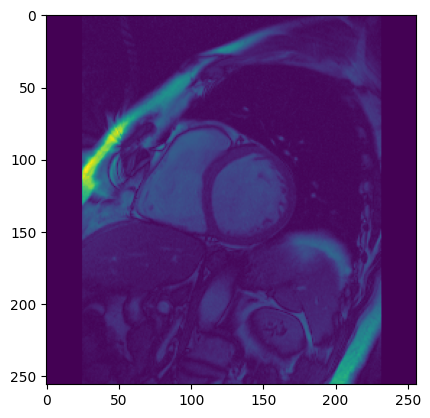

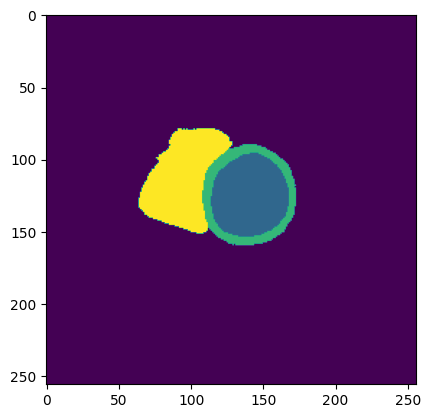

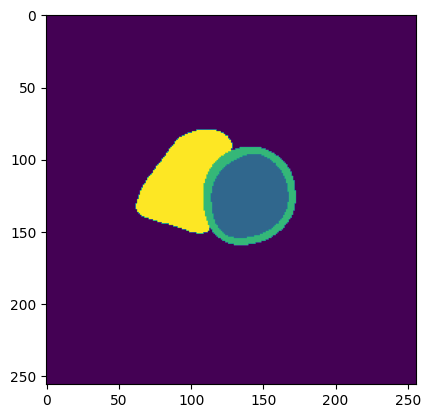

In [57]:
import matplotlib.pyplot as plt

idx = 5

plt.imshow(input[idx, 0].cpu().numpy())
plt.show()
plt.imshow(output[idx].cpu().argmax(0).detach().numpy())
plt.show()
plt.imshow(target[idx, 0].cpu().numpy())
plt.show()

In [103]:
from monai.metrics import DiceMetric

dice_metric = DiceMetric(include_background=False, reduction="none")

num_classes = output.shape[1]
if num_classes > 1:
    output = output.argmax(1)
output = torch.nn.functional.one_hot(output, num_classes=num_classes).moveaxis(-1, 1)

dsc = dice_metric(output, target)
dsc.nanmean(0)


tensor([0.9609, 0.8641, 0.9236])

In [100]:
dice_metric.aggregate(dsc)

RuntimeError: Boolean value of Tensor with more than one value is ambiguous

In [96]:
dsc.mean()

tensor(nan)

In [62]:
output.argmax(1).shape

torch.Size([32, 256, 256])

In [63]:
target.shape

torch.Size([32, 1, 256, 256])

In [15]:
pmri_datamodule = PMRIDataModule(
    data_dir="../../../../../data/PMRI/",
    vendor_assignment={'train': 'ge', 'test': 'philips'},
    batch_size=4
)

lightning_unet = LightningSegmentationModel(
    model = unet,
    binary_target=True
)


# default logger used by trainer (if tensorboard is installed)

wandb.finish()
wandb_logger = WandbLogger(project="lightning", log_model=True, name="unet")
# logger = TensorBoardLogger(save_dir=os.getcwd(), version=1, name="lightning_logs")
trainer = L.Trainer(
    limit_train_batches=100,
    limit_val_batches=25,
    limit_test_batches=100,
    max_epochs=20,
    logger=wandb_logger,
    callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=lightning_unet.patience * 2)],
    precision='16-mixed'
)
trainer.fit(lightning_unet, pmri_datamodule)

/usr/local/lib/python3.10/dist-packages/lightning/fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/loggers/wandb.py:396: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:

Epoch 19: 100%|██████████| 100/100 [00:12<00:00,  8.02it/s, v_num=yzdm]    

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 100/100 [00:12<00:00,  8.00it/s, v_num=yzdm]


In [24]:
pmri_datamodule.setup('fit')

In [35]:
dl = pmri_datamodule.val_dataloader()

In [36]:
batch = next(dl)

In [37]:
input = batch['data']
output = lightning_unet(input)
target = batch['target']

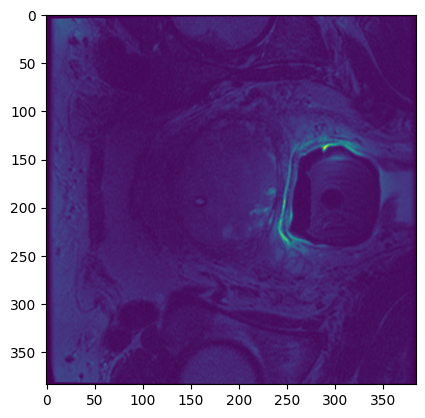

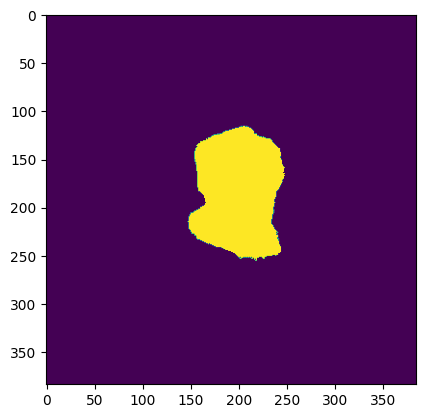

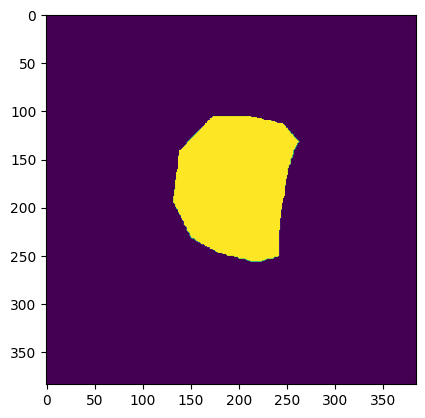

In [39]:
import matplotlib.pyplot as plt

plt.imshow(input[0, 0].cpu().numpy())
plt.show()
plt.imshow(output[0, 0].cpu().detach().numpy() > 0.5)
plt.show()
plt.imshow(target[0, 0].cpu().numpy())
plt.show()